# Installing Kaggle Library


In [1]:
#installing kaggle library
! pip install kaggle

In [2]:
#config the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Importing Twitter Sentiment Dataset
I fetch the dataset via kaggle API's for the Twitter Sentiment Dataset

In [7]:
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
  0% 0.00/80.9M [00:00<?, ?B/s]
100% 80.9M/80.9M [00:00<00:00, 1.17GB/s]


In [8]:
#extarcting zip file
from zipfile import ZipFile
dataset= '/content/sentiment140.zip'
with ZipFile (dataset, 'r') as zip:
  zip.extractall()
  print('Extraction Done!')

Extraction Done!


# Importing The Dependencies
numpy, pandas, re, nltk,...

In [62]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Reducing Dataset Complexity
I use stopwords to delete unimportant words for reducing the complexity and amount of data

In [14]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [16]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

# Data Processing

In [24]:
column_names= ['target', 'ids', 'date', 'flag', 'user', 'text']
twitter_data= pd.read_csv('/content/training.1600000.processed.noemoticon.csv', names=column_names, encoding= 'ISO-8859-1')

In [25]:
#Checking the number of the rows and columns
twitter_data.shape

(1600000, 6)

In [26]:
#Printing the first 10 rows of dataframe
twitter_data.head()

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [29]:
#Counting the missing values in dataset
twitter_data.isnull().sum()

,0
target,0
ids,0
date,0
flag,0
user,0
text,0


target
0    800000
1    800000
Name: count, dtype: int64




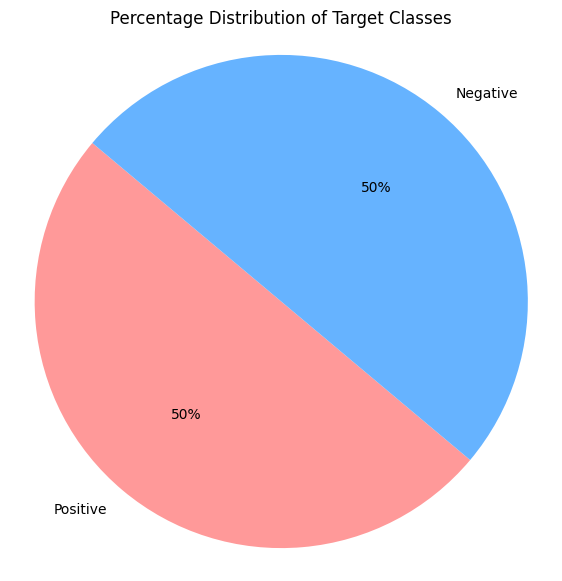

In [71]:
#checking the distribution of target column
print(twitter_data['target'].value_counts())
print('\n')
labels = ['Positive', 'Negative']
colors = ['#ff9999', '#66b3ff']

plt.figure(figsize=(7, 7))

twitter_data.target.value_counts().plot(
    kind='pie',
    labels=labels,
    colors=colors,
    autopct='%1.0f%%',
    startangle=140
)

plt.title('Percentage Distribution of Target Classes')
plt.ylabel('')
plt.axis('equal')
plt.show()


# Convertion Target 4 To 1
In column target I convert target from 4 to 1 for better presentation of negative (0) and Positive (1) tweets

In [33]:
twitter_data.replace({'target':{4:1}}, inplace=True)

In [34]:
twitter_data['target'].value_counts()

,count
target,
0,800000
1,800000


# Stemming

The process of reducing a word to its root word

In [35]:
port_stem= PorterStemmer()

In [36]:
def stemming(content):
  stemmed_content= re.sub('[^a-zA-Z]', ' ', content)
  stemmed_content= stemmed_content.lower()
  stemmed_content= stemmed_content.split()
  stemmed_content= [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
  stemmed_content= ' '.join(stemmed_content)
  return stemmed_content

In [37]:
twitter_data['stemmed_content']=twitter_data['text'].apply(stemming)

In [38]:
twitter_data.head()

,target,ids,date,flag,user,text,stemmed_content
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",switchfoot http twitpic com zl awww bummer sho...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,upset updat facebook text might cri result sch...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,kenichan dive mani time ball manag save rest g...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",nationwideclass behav mad see


# Seperating The Data and Values

In [39]:
X= twitter_data['stemmed_content'].values
Y= twitter_data['target'].values

# Seperating the data to training data and test data

In [40]:
X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [41]:
print(X.shape, X_train.shape, X_test.shape)

(1600000,) (1280000,) (320000,)


# Feature Extraction

As ML models doesn't undrestand the text I want to convert textual data to numerical data

In [42]:
vectorizer= TfidfVectorizer()
X_train= vectorizer.fit_transform(X_train)
X_test= vectorizer.transform(X_test)

# Training The Machine Learning Model
using logistic regression as machine learning model for classifying the data

In [50]:
model= LogisticRegression(max_iter=1000)

In [51]:
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

# Model Evaluation
Accuracy Score on the training data

In [52]:
X_trained_prediction= model.predict(X_train)
training_data_accuracy= accuracy_score(X_trained_prediction, Y_train)
print('Accuracy score on the training data:', training_data_accuracy)

Accuracy score on the training data: 0.79871953125


In [54]:
X_test_prediction= model.predict(X_test)
testing_data_accuracy= accuracy_score(X_test_prediction, Y_test)
print('Accuracy score on the testing data:', testing_data_accuracy)

Accuracy score on the testing data: 0.77668125


# Save The Trained Model

In [56]:
import pickle

In [57]:
file_name= 'trained_model.sav'
pickle.dump(model, open(file_name, 'wb'))

# Using The Saved Model For Future Predictions

In [59]:
loaded_model= pickle.load(open('/content/trained_model.sav', 'rb'))

In [60]:
X_new= X_test[200]
print('True Label:',Y_test[200])

prediction= loaded_model.predict(X_new)
print('Predicted Label:',prediction)

if prediction[0]==0:
  print('Negative Tweet')
else:
  print('Positive Tweet')

True Label: 1
Predicted Label: [1]
Positive Tweet
